<a href="https://colab.research.google.com/github/PasinduDil/ML-exercise/blob/main/purchase_data_visualization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/content/purchase_data.csv")

In [4]:
print("Dataset Head:")
df.head()

Dataset Head:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)


In [6]:
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

In [7]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())
df.dropna(subset=['CustomerID'], inplace=True)


Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
MonthYear           0
Revenue             0
dtype: int64


In [9]:
monthly_revenue = df.groupby('MonthYear')['Revenue'].sum()
monthly_transactions = df.groupby('MonthYear')['InvoiceNo'].nunique()

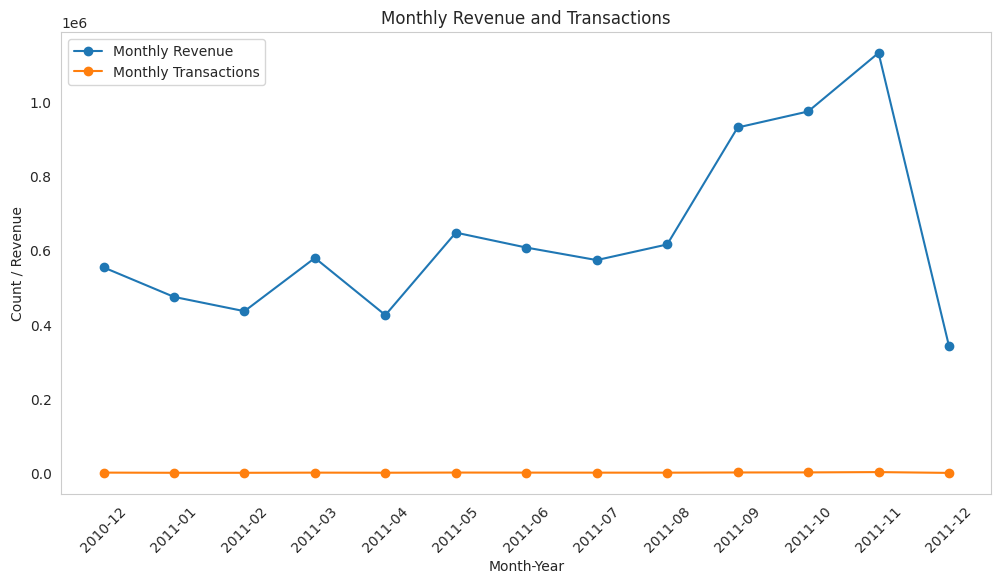

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue, label='Monthly Revenue', marker='o')
plt.plot(monthly_transactions.index.astype(str), monthly_transactions, label='Monthly Transactions', marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue and Transactions")
plt.xlabel("Month-Year")
plt.ylabel("Count / Revenue")
plt.legend()
plt.grid()
plt.show()

In [11]:
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products by Revenue:")
print(product_revenue)


Top 10 Products by Revenue:
Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64


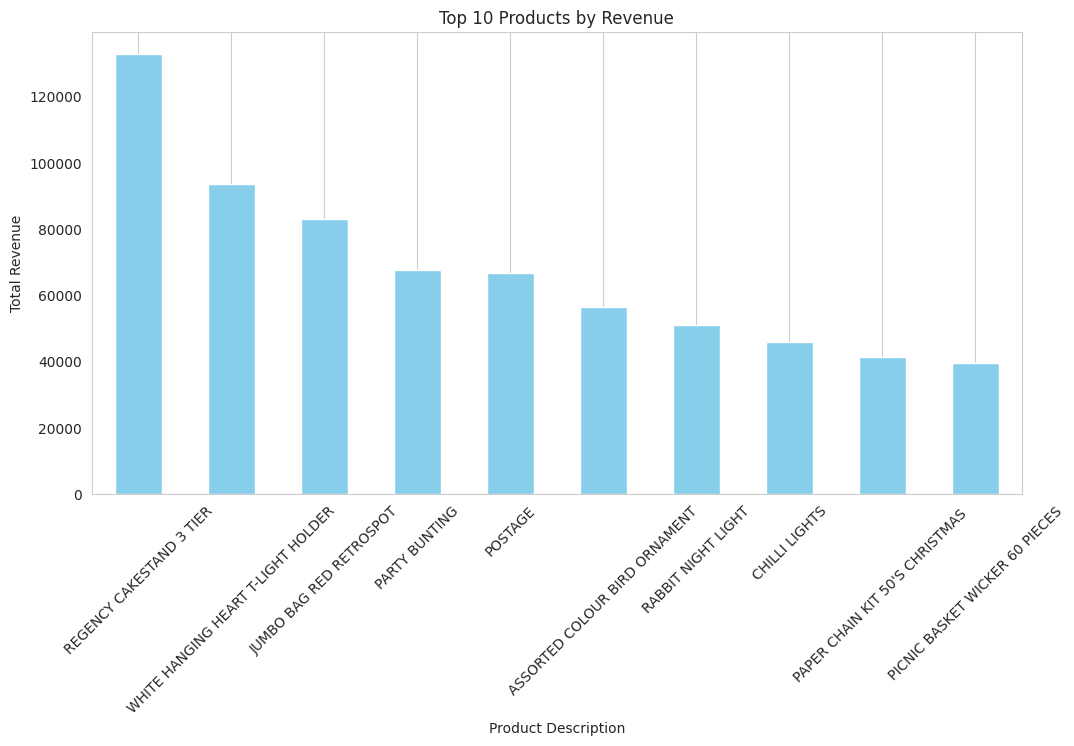

In [12]:
plt.figure(figsize=(12, 6))
product_revenue.plot(kind='bar', color='skyblue')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Description")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [13]:
df['Month'] = df['InvoiceDate'].dt.month
seasonal_sales = df.groupby(['Month', 'Description'])['Revenue'].sum().reset_index()
seasonal_top_product = seasonal_sales.groupby('Description')['Revenue'].sum().nlargest(5).index

seasonal_sales_top = seasonal_sales[seasonal_sales['Description'].isin(seasonal_top_product)]

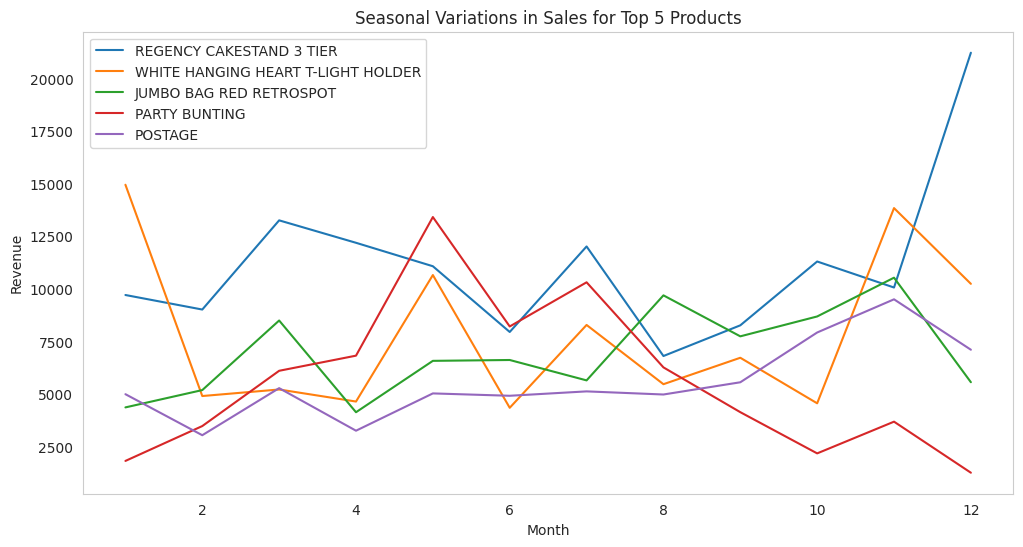

In [14]:
plt.figure(figsize=(12, 6))
for product in seasonal_top_product:
    product_sales = seasonal_sales_top[seasonal_sales_top['Description'] == product]
    plt.plot(product_sales['Month'], product_sales['Revenue'], label=product)
plt.title("Seasonal Variations in Sales for Top 5 Products")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid()
plt.show()

In [15]:
customer_purchases = df.groupby('CustomerID')['InvoiceNo'].nunique()
print("\nCustomer Purchasing Patterns:")
print(customer_purchases.describe())


Customer Purchasing Patterns:
count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64


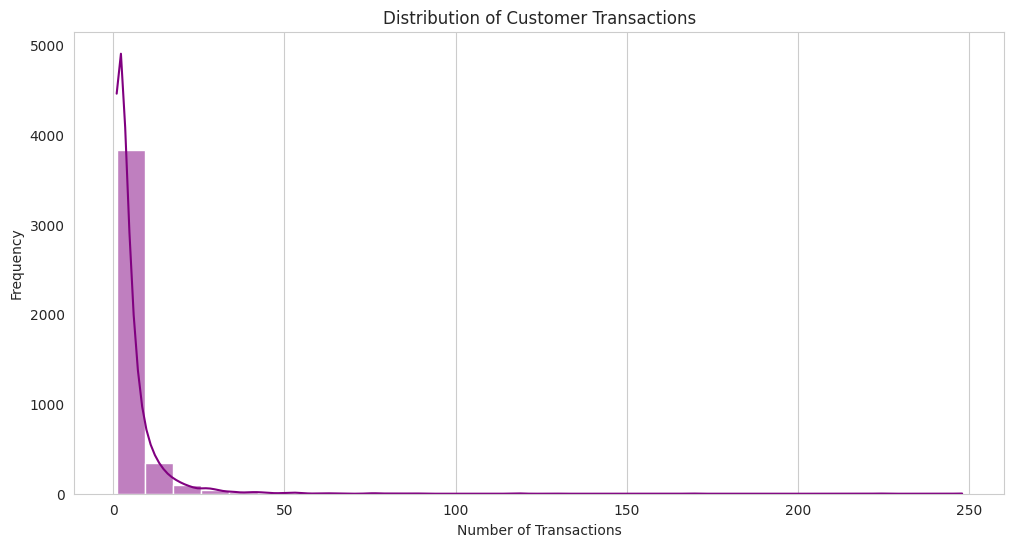

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(customer_purchases, bins=30, kde=True, color='purple')
plt.title("Distribution of Customer Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()

In [17]:
with open("Statistical_Programming_Report.pdf", "w") as f:
    f.write("Statistical Programming Assessment Report\n")
    f.write("=========================================\n\n")
    f.write("1. Monthly Revenue and Transactions:\n")
    f.write(f"Monthly Revenue: \n{monthly_revenue}\n\n")
    f.write(f"Monthly Transactions: \n{monthly_transactions}\n\n")
    f.write("2. Top 10 Products by Revenue:\n")
    f.write(f"{product_revenue}\n\n")
    f.write("3. Seasonal Variations:\n")
    f.write(f"Seasonal Sales Data: \n{seasonal_sales}\n\n")
    f.write("4. Customer Purchasing Behavior:\n")
    f.write(f"Customer Transactions Description: \n{customer_purchases.describe()}\n\n")